In [5]:
import os
import torch
from PIL import Image, ImageFilter
from diffusers.utils import load_image
from diffusers import AutoPipelineForInpainting, LCMScheduler

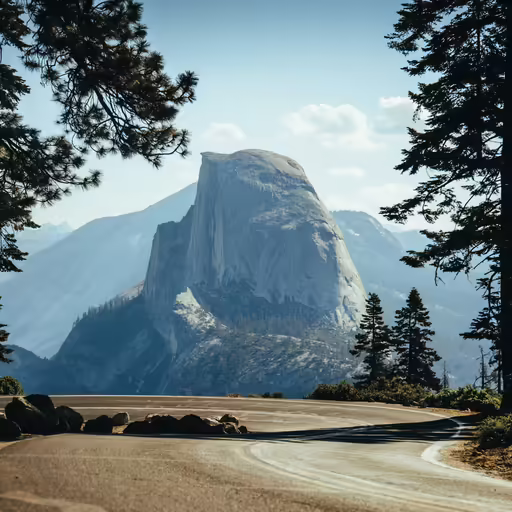

In [6]:
init_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png")
mask_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png")

init_image

In [ ]:
prompt = "a black cat with glowing eyes, cute, adorable, cinematic lighting, highly detailed"
negative_prompt = "bad anatomy, deformed, ugly, disfigured, blurry, low quality"

pipe = AutoPipelineForInpainting.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-inpainting",
    torch_dtype=torch.float32,   # CPU-friendly
)

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


diffusion_pytorch_model.bin:  29%|##9       | 1.01G/3.44G [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-inpainting/resolve/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet/diffusion_pytorch_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


diffusion_pytorch_model.bin:  44%|####4     | 1.52G/3.44G [00:00<?, ?B/s]

...

diffusion_pytorch_model.bin:  61%|######1   | 2.11G/3.44G [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-inpainting/resolve/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet/diffusion_pytorch_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


diffusion_pytorch_model.bin:  85%|########4 | 2.92G/3.44G [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-inpainting/resolve/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet/diffusion_pytorch_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


diffusion_pytorch_model.bin:  85%|########5 | 2.93G/3.44G [00:00<?, ?B/s]

In [ ]:
pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)
pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")

# These help with memory; they usually do not hurt CPU testability.
pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

generator = torch.Generator(device="cpu").manual_seed(42)

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=4,
    guidance_scale=1.5,   # try 1.0, 1.5, 2.0, then 4.0
    generator=generator,
).images[0]

image